<a href="https://colab.research.google.com/github/cibelerusso/FundamentosemCienciasdeDados/blob/main/Notebooks/Aprendizado_Supervisionado_Aula_12_Arvore_de_decis%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Árvores de decisão

## 5500004 Fundamentos em Ciências de Dados


por **Cibele Russo**

**ICMC/USP - São Carlos SP**


Referências:  

MOREIRA, João Mendes; CARVALHO, André C. P. L. F. de; HORVÁTH, Tomáš. A General Introduction to Data Analytics. 1. ed. Hoboken, NJ: John Wiley & Sons, Inc., 2019.

FACELI, K., LORENA, A. C., GAMA, J., ALMEIDA, T. A. D., & CARVALHO, A. C. P. D. L. F. D. (2021). Inteligência artificial: uma abordagem de aprendizado de máquina.

Notebook criado com apoio de ferramentas da IA generativa: NotebookLM e ChatGPT.

Dados gerados artificialmente pela autora, baseado em Faceli e outros.



# Árvores de Decisão e de Regressão

- As árvores de decisão (e de regressão) são algoritmos baseados em **busca** que constroem modelos com uma estrutura hierárquica, facilitando a interpretação humana através de um formato semelhante a um fluxograma.
- Utiliza a estratégia **dividir para conquistar** para resolver um problema de decisão.

## 1. Estrutura de uma Árvore
Uma árvore de decisão é composta por três elementos principais:
*   **Nó Raiz:** O nó no topo da árvore que recebe todos os dados de treinamento.
*   **Nós Internos:** Representam testes em atributos preditivos específicos. Cada resultado do teste leva a um ramo.
*   **Nós Folha:** Representam o desfecho final ou o valor do atributo alvo (classe ou valor numérico).

## 2. O Processo de Indução

A construção da árvore geralmente segue uma estratégia de **"dividir para conquistar"**:

1.  **Divisão Recursiva:** O algoritmo começa na raiz e divide os dados em subconjuntos baseados no atributo que melhor separa as classes.

2.  **Medidas de Impureza:** Para escolher o melhor atributo, utilizam-se cálculos como o **Índice Gini** (usado no algoritmo CART: Classification and Regression Tree) ou **Ganho de Informação** (usado no ID3 e C4.5). O objetivo é tornar os nós filhos o mais "puros" (homogêneos) possível.

3.  **Critérios de Parada:** O processo para quando todos os objetos em um nó pertencem à mesma classe, quando não há mais atributos para dividir ou quando o nó atinge um tamanho mínimo pré-definido.


## 3. Classificação vs. Regressão
Embora a estrutura seja similar, existem diferenças cruciais dependendo da tarefa:
*   **Árvores de Classificação:** O rótulo da folha é determinado por **votação por maioria**. Utilizam medidas de impureza como Gini ou Entropia.
*   **Árvores de Regressão:** O rótulo da folha é a **média** dos valores alvo dos objetos naquele nó. A medida de impureza comum é a **redução de variância**.

## 4. O Problema do Sobreajuste (overfitting) e a Poda
Árvores muito profundas tendem a "decorar" o ruído dos dados de treinamento (**overfitting**), perdendo a capacidade de generalização. Para mitigar isso, utiliza-se a **Poda**:
*   **Pré-poda:** Interrompe o crescimento da árvore antes que ela se torne muito complexa.
*   **Pós-poda:** Remove ramos que não contribuem significativamente para a precisão do modelo após a árvore ter sido totalmente construída.

## 5. Resumo: Vantagens e Desvantagens

| **Vantagens** | **Desvantagens** |
| :--- | :--- |
| **Interpretáveis:** Podem ser lidas como um conjunto de regras Se-então. | **Instabilidade:** Pequenas mudanças nos dados podem gerar árvores muito diferentes. |
| **Sem Pré-processamento:** Robustas a outliers e não exigem normalização de dados. | **Divisões Axiais:** Só dividem o espaço com linhas horizontais ou verticais, o que pode ser limitante para problemas complexos. |
| **Seleção de Atributos:** Realizam a seleção de variáveis internamente. | **Ótimos Locais:** A busca gulosa pode não encontrar a árvore globalmente ótima. |



# Árvore de decisão ou regressão:

                    Conjunto de Dados
                           │
                           ▼
              Escolher o melhor atributo
                           │
                           ▼
                    Dividir os dados
                    /             \
                   /               \
                  ▼                 ▼
          Valor = Sim         Valor = Não
                  │                 │
                  ▼                 ▼
       Os exemplos são      Ainda há mistura
         da mesma classe?      de classes?
                  │                 │
            Sim ──┘                 └── Sim
                  │                        │
                  ▼                        ▼
           Folha (A)              Escolher novo
                                   atributo
                                        │
                                        ▼
                                  Dividir dados

## Exemplo: Problema "Jogar Tênis"

O problema "Jogar Tênis" é um exemplo clássico utilizado para ilustrar o funcionamento de árvores de decisão. O objetivo é decidir jogar ou não jogar tênis com base em condições climáticas, como temperatura, umidade, vento e aparência do tempo.

No exemplo apresentado, a decisão começa pelo atributo Temperatura. Quando a temperatura é agradável, a decisão é diretamente Jogar. Quando a temperatura é quente, é necessário analisar também a Umidade. Se a umidade for alta, a decisão é Não Jogar; caso contrário, a decisão é Jogar.

Esse exemplo mostra como uma árvore de decisão transforma regras de decisão em uma estrutura hierárquica simples, interpretável e capaz de apoiar processos de classificação.

                                 Nó Raiz
                                     │
                                     ▼
                               Temperatura?
                      ┌──────────────┴──────────────┐
                      │                             │
                      ▼                             ▼
                  Quente                       Agradável
                      │                             │
                      ▼                             ▼
                 Umidade?                    Folha: Jogar
               ┌──────┴──────┐
               │             │
               ▼             ▼
      Folha: Não Jogar   Folha: Jogar

## Para cada nó, como se decide por qual variável fazer a próxima partição nos dados?

           Dados no Nó Atual
                   │
                   ▼
      ┌─────────────────────────┐
      │ Calcular Impureza       │
      │ (Gini ou Entropia)      │
      └─────────────────────────┘
                   │
                   ▼
      ┌─────────────────────────┐
      │ Testar cada atributo    │
      └─────────────────────────┘
                   │
                   ▼
      ┌─────────────────────────┐
      │ Escolher maior redução  │
      │ de impureza             │
      └─────────────────────────┘
                   │
                   ▼
              Realizar
               Divisão

### Exemplo

            Temperatura?
             /       \
          Quente    Agradável
            |         |
        Não Jogar      Jogar


# Índice de Gini em Árvores de Decisão

O **Índice de Gini** é uma medida de **impureza** utilizada pelo algoritmo CART (*Classification and Regression Trees*) para decidir qual atributo deve ser usado em cada divisão da árvore.

A ideia é simples:

- Um nó é **puro** quando todos os exemplos pertencem à mesma classe.
- Um nó é **impuro** quando contém exemplos de várias classes.
- Quanto **menor** o Índice de Gini, **melhor** é a divisão.







# 1. Fórmula do Índice de Gini

$Gini(t)=1-\displaystyle\sum_{i=1}^{c} p_i^2$

onde:

- $p_i$ = proporção de exemplos da classe $i$ no nó.
- $c$ = número de classes.




## Interpretação

| Situação | Gini |
|-----------|-------|
| Nó totalmente puro | 0 |
| Classes bem misturadas | Alto |
| Melhor divisão | Menor Gini |




In [ ]:
1-(0.5**2+0.5**2)

0.5

In [ ]:
1-(0.1**2+0.9**2)

0.17999999999999994

# 2. Exemplo Simples

Suponha um nó com 10 exemplos:

| Classe | Quantidade |
|----------|------------|
| Sim | 8 |
| Não | 2 |

Então:

$p_{Sim}=\frac{8}{10}=0,8$

$p_{Não}=\frac{2}{10}=0,2$

Aplicando a fórmula:

$Gini = 1-(0,8^2+0,2^2)$

$Gini = 1-(0,64+0,04)$

$Gini = 0,32$

Resultado:

$Gini = 0,32$

O nó possui alguma mistura, mas ainda é relativamente puro.










# 3. Nó Perfeitamente Puro

Imagine:

| Classe | Quantidade |
|----------|------------|
| Sim | 10 |
| Não | 0 |

Então:

$p_{Sim}=1$

$p_{Não}=0$

$Gini=1-(1^2+0^2)$

$Gini=0$

O nó é totalmente puro.

# 4. Máxima Impureza

Para duas classes igualmente distribuídas:

| Classe | Quantidade |
|----------|------------|
| Sim | 5 |
| Não | 5 |

Temos:

$p_{Sim}=0,5$

$p_{Não}=0,5$

$Gini=1-(0,5^2+0,5^2)$

$Gini=1-(0,25+0,25)$

$Gini=0,5$

Resultado:

$Gini = 0,5$

Para duas classes, este é o valor máximo de impureza.

# 5. Como a Árvore Escolhe uma Divisão

Considere o seguinte conjunto:

```text
                20 observações
              (12 Sim, 8 Não)
```

Gini do nó pai:

$Gini_{pai}=1-\left(\frac{12}{20}\right)^2-\left(\frac{8}{20}\right)^2$

$Gini_{pai}=1-(0,36+0,16)$

$Gini_{pai}=0,48$


### Possível divisão

```text
                  Idade?
                 /      \
             Jovem      Adulto
          (8S,2N)      (4S,6N)
```

### Filho Esquerdo

$Gini_E=1-(0,8^2+0,2^2)$

$Gini_E=0,32$

### Filho Direito

$Gini_D=1-(0,4^2+0,6^2)$

$Gini_D=0,48$




# 6. Gini da Divisão

A qualidade da divisão é calculada usando a média ponderada dos filhos:

$Gini_{split}=
\sum_{j=1}^{k}
\frac{N_j}{N}
Gini(j)$

onde:

- $N_j$ = número de exemplos no filho $j$
- $N$ = número total de exemplos
- $k$ = número de filhos

No exemplo:

$Gini_{split}
=\frac{10}{20}(0,32)+\frac{10}{20}(0,48)$

$Gini_{split}=0,16+0,24$

$Gini_{split}=0,40$


# 7. Ganho Obtido

A redução de impureza é:

$
\text{Redução}
=
Gini_{pai}
-
Gini_{split}
$

$
\text{Redução}
=
0,48-0,40
$

$
\text{Redução}
=
0,08
$

Quanto maior essa redução, melhor a divisão.



# Diagrama do Processo


                Nó Pai
             (12S, 8N)
             Gini=0,48
                  │
                  ▼
            Teste: Idade
             /         \
            /           \
           ▼             ▼
      (8S,2N)       (4S,6N)
     Gini=0,32     Gini=0,48
           \         /
            \       /
             ▼     ▼
       Gini Split = 0,40
             │
             ▼
    Redução = 0,08


# Regra de Decisão do CART

Para cada atributo:

1. Simular a divisão
2. Calcular o Gini dos filhos
3. Calcular o Gini Split
4. Escolher a divisão com MENOR Gini Split (ou MAIOR redução de Gini)


Essa estratégia é repetida recursivamente até que os nós fiquem suficientemente puros ou algum critério de parada seja atingido.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import random

random.seed(1)

# Carregando os dados
dados = pd.read_csv('https://raw.githubusercontent.com/cibelerusso/Datasets/refs/heads/main/jogartenis_aumentado.csv')
dados

dados = pd.read_csv('https://raw.githubusercontent.com/cibelerusso/Aprendizado_de_Maquina/refs/heads/main/Dados/JogarTenis.csv')
dados


,Tempo,Temperatura,Umidade,Vento,Joga
0,Chuvoso,22,91,Sim,Não
1,Ensolarado,21,70,Não,Sim
2,Ensolarado,27,90,Sim,Não
3,Nublado,28,86,Não,Sim
4,Chuvoso,21,96,Não,Sim
5,Chuvoso,18,70,Sim,Não
6,Nublado,18,65,Sim,Sim
7,Nublado,22,90,Sim,Sim
8,Ensolarado,24,70,Sim,Sim
9,Chuvoso,20,80,Não,Sim


In [ ]:
dados['Tempo'] = dados['Tempo'].map({
    'Ensolarado': 1,
    'Nublado': 2,
    'Chuvoso': 3
})

dados['Vento'] = dados['Vento'].map({
    'Sim': 1,
    'Não': 0
})

dados['Joga'] = dados['Joga'].map({
    'Sim': 1,
    'Não': 0
})

In [ ]:
dados

,Tempo,Temperatura,Umidade,Vento,Joga
0,3,22,91,1,0
1,1,21,70,0,1
2,1,27,90,1,0
3,2,28,86,0,1
4,3,21,96,0,1
5,3,18,70,1,0
6,2,18,65,1,1
7,2,22,90,1,1
8,1,24,70,1,1
9,3,20,80,0,1


In [ ]:
# Separa as preditoras (X) e a resposta (y)
X = dados.drop('Joga', axis=1)
y = dados['Joga']

In [ ]:
X

,Tempo,Temperatura,Umidade,Vento,Joga
0,1,23,70,0,1
1,3,18,82,0,1
2,3,26,60,1,0
3,2,18,96,0,1
4,1,22,80,1,1
...,...,...,...,...,...
495,1,20,91,1,0
496,2,30,70,0,1
497,1,25,82,0,1
498,3,26,85,1,0


In [ ]:
.8*14

11.200000000000001

In [ ]:
# dados de treinamento e teste: 80% para treinamento e 20% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
X_train

,Tempo,Temperatura,Umidade,Vento
12,1,22,95,0
5,3,18,70,1
8,1,24,70,1
2,1,27,90,1
1,1,21,70,0
13,3,24,80,0
4,3,21,96,0
7,2,22,90,1
10,2,27,75,0
3,2,28,86,0


In [ ]:
# Cria uma árvore de decisão
arvore = DecisionTreeClassifier(max_depth=5, criterion='gini')

# Treina a árvore de decisão usando os dados de treinamento
arvore.fit(X_train, y_train)

# Usa a árvore de decisão para prever os rótulos da base de teste
y_pred = arvore.predict(X_test)
y_pred


array([1, 0, 1])

In [ ]:
y_test, y_pred

(9     1
 11    0
 0     0
 Name: Joga, dtype: int64,
 array([1, 0, 1]))

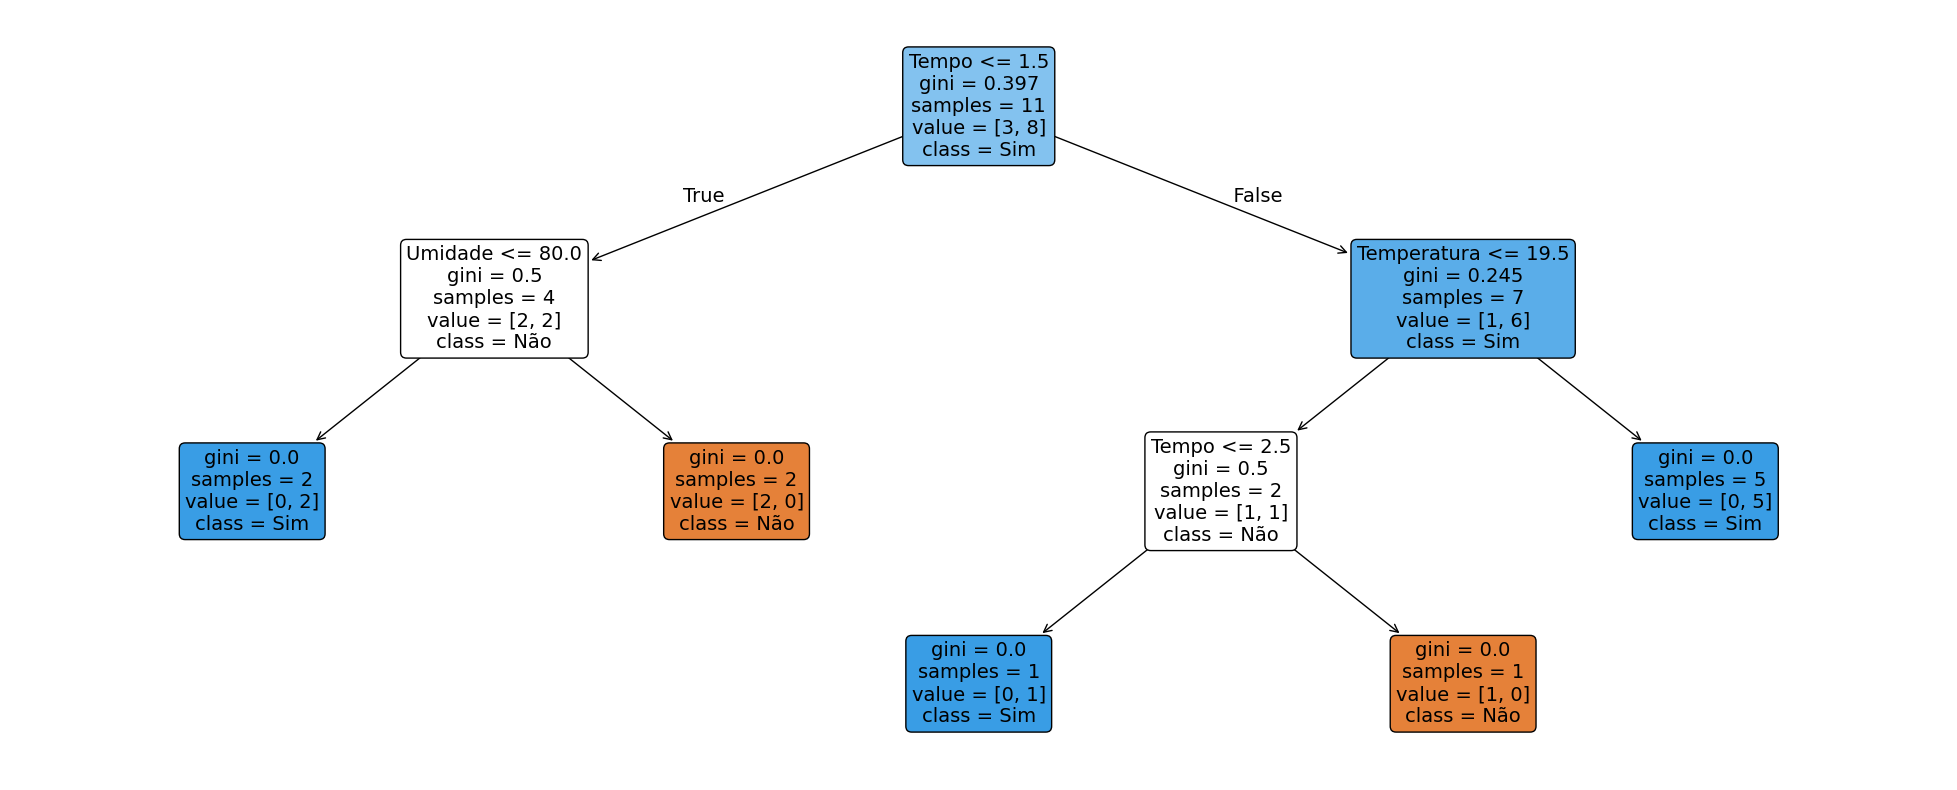

In [ ]:
plt.figure(figsize=(25, 10))

a = plot_tree(
    arvore,
    feature_names=X_train.columns,
    class_names=['Não', 'Sim'],
    filled=True,
    rounded=True,
    fontsize=14
)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Acurácia
acc = accuracy_score(y_test, y_pred)

print('Métricas de desempenho para aprendizado supervisionado em classificação binária')
print("\nAcurácia:", np.round(acc,3))

# Para a classe 1
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
print("\nPrecisão (para a classe 1):", np.round(precision,3))
print("Recall (para a classe 1):", np.round(recall,3))
print("F1-score (para a classe 1):", np.round(f1,3))

# Para a classe 0
precision = precision_score(y_test, y_pred, pos_label=0)
recall = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)
print("\nPrecisão (para a classe 0):", np.round(precision,3))
print("Recall (para a classe 0):", np.round(recall,3))
print("F1-score (para a classe 0):", np.round(f1,3))

Métricas de desempenho para aprendizado supervisionado em classificação binária

Acurácia: 0.667

Precisão (para a classe 1): 0.5
Recall (para a classe 1): 1.0
F1-score (para a classe 1): 0.667

Precisão (para a classe 0): 1.0
Recall (para a classe 0): 0.5
F1-score (para a classe 0): 0.667


# Escolha da árvore por validação cruzada

In [ ]:
from sklearn.model_selection import GridSearchCV

# Uso da validação cruzada para encontar a melhor árvore
param_grid = {
    'max_depth': range(2, 4),
    'min_samples_split': range(2, 3),
    'min_samples_leaf': range(2, 8)
}

# Realiza a busca em grid com cross-validation para encontrar a melhor árvore
grid = GridSearchCV(arvore, param_grid, cv=5)
grid.fit(X_train, y_train)

# Usa a árvore de decisão para prever os rótulos da base de teste
y_pred = grid.predict(X_test)

# Melhor árvore escolhida
print(f"Melhores parâmetros: {grid.best_params_}")
print(f"Acurácia da melhor árvore: {grid.best_score_}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Melhores parâmetros: {'max_depth': 2, 'min_samples_leaf': 5, 'min_samples_split': 2}
Acurácia da melhor árvore: 0.7333333333333333


In [ ]:
# Acurácia
acc = accuracy_score(y_test, y_pred)

print('Métricas de desempenho para aprendizado supervisionado em classificação binária')
print("\nAcurácia:", np.round(acc,3))

# Para a classe 1
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
print("\nPrecisão (para a classe 1):", np.round(precision,3))
print("Recall (para a classe 1):", np.round(recall,3))
print("F1-score (para a classe 1):", np.round(f1,3))

# Para a classe 0
precision = precision_score(y_test, y_pred, pos_label=0)
recall = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)
print("\nPrecisão (para a classe 0):", np.round(precision,3))
print("Recall (para a classe 0):", np.round(recall,3))
print("F1-score (para a classe 0):", np.round(f1,3))

Métricas de desempenho para aprendizado supervisionado em classificação binária

Acurácia: 0.953

Precisão (para a classe 1): 1.0
Recall (para a classe 1): 0.932
F1-score (para a classe 1): 0.965

Precisão (para a classe 0): 0.87
Recall (para a classe 0): 1.0
F1-score (para a classe 0): 0.931


# Pesquisar:

Métodos ensemble: Bagging, boosting e florestas aleatórias